In [4]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

# Compton y calculation
from astropy.constants import k_B, m_p, c, sigma_T, m_e
from astropy import units as u

from astropy.coordinates import SkyCoord
import astropy.units as u

import utils as ut


# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

In [1]:
def calc_y_and_err(tau, tau_err, Te, Te_err):
    Te = Te * u.keV
    Te_err = Te_err * u.keV
    Te_K = (Te / k_B).to(u.K)    
    Te_err_K = (Te_err / k_B).to(u.K)

    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    yerr = y * np.sqrt((tau_err / tau)**2 + (Te_err_K / Te_K)**2)

    return y.value, yerr.value

def get_y_vector(samples, idx_tau, idx_Te):
    Te = samples[:, idx_Te] * u.keV
    tau = samples[:, idx_tau]
    Te_K = (Te / k_B).to(u.K)
    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    return y.value

def calc_mean_and_std(samples, idx):
    data = samples[:, idx]

    mcmc_run = np.percentile(data, [16, 50, 84])
    err = .5 * (mcmc_run[2] - mcmc_run[0])
    
    # Calculate bin width using Freedman-Diaconis rule
    n = len(data)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    bin_width = 2 * iqr * n**(-1/3)

    # Calculate number of bins using bin width
    num_bins = int((np.max(data) - np.min(data)) / bin_width)

    # Create histogram
    hist, bin_edges = np.histogram(data, bins=num_bins, density=True)

    # Find bin with maximum value (estimate of mode)
    mode_bin = np.argmax(hist)
    mode_value = 0.5 * (bin_edges[mode_bin] + bin_edges[mode_bin + 1])

    mean = mode_value
    std = err
    return mean, std

In [2]:
# indices for the chain parameters
param_indices = {
    'ra_a401': 0,
    'dec_a401': 1,
    'beta_a401': 2,
    'rc_a401': 3,
    'R_a401': 4,
    'theta_a401': 5,
    'tau_a401': 6,
    'Te_a401': 7,
    'AD_a401': 8,
    'ra_a399': 9,
    'dec_a399': 10,
    'beta_a399': 11,
    'rc_a399': 12,
    'R_a399': 13,
    'theta_a399': 14,
    'tau_a399': 15,
    'Te_a399': 16,
    'AD_a399': 17,
    'fil_ra': 18,
    'fil_dec': 19,
    'fil_l0': 20,
    'fil_w0': 21,
    'tau_fil': 22,
    'Te_fil': 23,
    'fil_AD': 24,
    'fil_vavg': 25
}

case10 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case10/chain.h5"
case24 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case24/chain.h5"
case25 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case25/chain.h5"
case26 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case26/chain.h5"
case27 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case27/chain.h5"
case28 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case28/chain.h5"
case29 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case29/chain.h5"
case30 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case30/chain.h5"
case31 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case31/chain.h5"
case32 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case32/chain.h5"
case33 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case33/chain.h5"

In [19]:
burnin = 60000
thin = 1
samples_case10 = emcee.backends.HDFBackend(case10).get_chain(discard=burnin, flat=True, thin=thin)
samples_case24 = emcee.backends.HDFBackend(case24).get_chain(discard=burnin, flat=True, thin=thin)
samples_case25 = emcee.backends.HDFBackend(case25).get_chain(discard=burnin, flat=True, thin=thin)
samples_case26 = emcee.backends.HDFBackend(case26).get_chain(discard=burnin, flat=True, thin=thin)
samples_case27 = emcee.backends.HDFBackend(case27).get_chain(discard=burnin, flat=True, thin=thin)
samples_case28 = emcee.backends.HDFBackend(case28).get_chain(discard=30000, flat=True, thin=thin)
samples_case29 = emcee.backends.HDFBackend(case29).get_chain(discard=30000, flat=True, thin=thin)
samples_case30 = emcee.backends.HDFBackend(case30).get_chain(discard=30000, flat=True, thin=thin)
samples_case31 = emcee.backends.HDFBackend(case31).get_chain(discard=30000, flat=True, thin=thin)
samples_case32 = emcee.backends.HDFBackend(case32).get_chain(discard=30000, flat=True, thin=thin)
samples_case33 = emcee.backends.HDFBackend(case33).get_chain(discard=30000, flat=True, thin=thin)

print("Number of iterations for case 10: {:.0f}".format(samples_case10.shape[0] / emcee.backends.HDFBackend(case10).shape[0]))
print("Number of iterations for case 24: {:.0f}".format(samples_case24.shape[0] / emcee.backends.HDFBackend(case24).shape[0]))
print("Number of iterations for case 25: {:.0f}".format(samples_case25.shape[0] / emcee.backends.HDFBackend(case25).shape[0]))
print("Number of iterations for case 26: {:.0f}".format(samples_case26.shape[0] / emcee.backends.HDFBackend(case26).shape[0]))
print("Number of iterations for case 27: {:.0f}".format(samples_case27.shape[0] / emcee.backends.HDFBackend(case27).shape[0]))
print("Number of iterations for case 28: {:.0f}".format(samples_case28.shape[0] / emcee.backends.HDFBackend(case28).shape[0]))
print("Number of iterations for case 29: {:.0f}".format(samples_case29.shape[0] / emcee.backends.HDFBackend(case29).shape[0]))
print("Number of iterations for case 30: {:.0f}".format(samples_case30.shape[0] / emcee.backends.HDFBackend(case30).shape[0]))
print("Number of iterations for case 31: {:.0f}".format(samples_case31.shape[0] / emcee.backends.HDFBackend(case31).shape[0]))
print("Number of iterations for case 32: {:.0f}".format(samples_case32.shape[0] / emcee.backends.HDFBackend(case32).shape[0]))  
print("Number of iterations for case 33: {:.0f}".format(samples_case33.shape[0] / emcee.backends.HDFBackend(case33).shape[0]))

Number of iterations for case 10: 49374
Number of iterations for case 24: 34346
Number of iterations for case 25: 16931
Number of iterations for case 26: 20195
Number of iterations for case 27: 17390
Number of iterations for case 28: 33895
Number of iterations for case 29: 16351
Number of iterations for case 30: 16233
Number of iterations for case 31: 18512
Number of iterations for case 32: 17867
Number of iterations for case 33: 18051


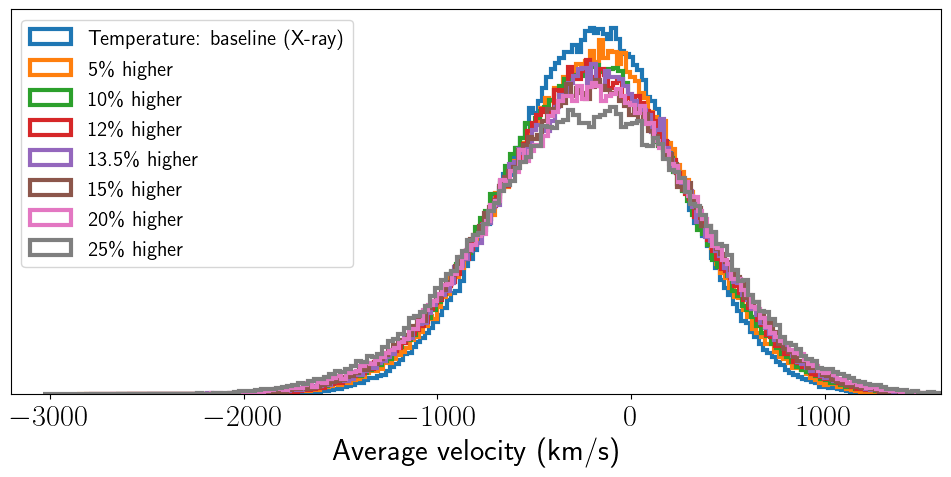

In [21]:
cases = [
    (samples_case10, "case10"),
    (samples_case24, "case24"), 
    (samples_case25, "case25"),
    (samples_case26, "case26"),
    (samples_case27, "case27"),
    (samples_case28, "case28"),
    (samples_case29, "case29"),
    (samples_case30, "case30"),
    (samples_case31, "case31"),
    (samples_case32, "case32"),
    (samples_case33, "case33")
]

case_labels = ["Temperature: baseline (X-ray)", 
               r"25\% higher",
               r"15\% higher",
               r"10\% higher",
               r"5\% higher",
               r"10\% higher",
               r"12\% higher",
               r"13.5\% higher",
               r"15\% higher",
               r"20\% higher",
               r"25\% higher"]

plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)    
#plt.hist(samples_case25[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
#plt.hist(samples_case26[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['fil_vavg']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Average velocity (km/s)')
plt.legend(fontsize=15)
plt.gca().set_yticks([])
#plt.savefig("average_velocity_distributions.png", bbox_inches='tight')
plt.xlim(-3200, 1600)
plt.show()
# Plotting the Compton y distributions for each case
# Plot the Compton y distributions for each case

In [8]:
# Compton y fits
# --- A401 ---
# Compton-y fit
compton_y_fits = {
    "ra_a401_mean": 44.751,
    "ra_a401_std": 0.002,
    "dec_a401_mean": 13.572,
    "dec_a401_std": 0.002,
    "beta_a401_mean": 0.82,
    "beta_a401_std": 0.05,
    "rc_a401_mean": 2.6,
    "rc_a401_std": 0.35,
    "R_a401_mean": 0.82,
    "R_a401_std": 0.055,
    "theta_a401_mean": 123,
    "theta_a401_std": 8.5,
    "y_a401_mean": 1.260e-04,
    "y_a401_std": 6.00e-06,
    
    "ra_a399_mean": 44.473,
    "ra_a399_std": 0.004,
    "dec_a399_mean": 13.03,
    "dec_a399_std": 0.003,
    "beta_a399_mean": 0.81,
    "beta_a399_std": 0.095,
    "rc_a399_mean": 3.0,
    "rc_a399_std": 0.65,
    "R_a399_mean": 0.93,
    "R_a399_std": 0.06,
    "theta_a399_mean": 133,
    "theta_a399_std": 26.5,
    "y_a399_mean": 8.100e-05,
    "y_a399_std": 6.00e-06,
    
    "fil_ra_mean": 44.68,
    "fil_ra_std": 0.02,
    "fil_dec_mean": 13.37,
    "fil_dec_std": 0.025,
    "fil_l0_mean": 12.3,
    "fil_l0_std": 1.55,
    "fil_w0_mean": 10.8,
    "fil_w0_std": 1.05,
    "y_fil_mean": 1.100e-05,
    "y_fil_std": 1.750e-06,
}

In [9]:
def result_comparer(samples, compton_y_fits, param_indices, cf_path):
    # create a dictionary of the sample results
    # create the labels first for the dictionary

    ## Take care of RA and DEC values 
    cf = ut.get_config_file(f'{cf_path}')

    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])

    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    a401_ra_pix = samples[:, param_indices['ra_a401']]
    a401_dec_pix = samples[:, param_indices['dec_a401']]

    a399_ra_pix = samples[:, param_indices['ra_a399']]
    a399_dec_pix = samples[:, param_indices['dec_a399']]

    fil_ra_pix = samples[:, param_indices['fil_ra']]
    fil_dec_pix = samples[:, param_indices['fil_dec']]

    ra_a401, dec_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)
    samples[:, param_indices['ra_a401']] = ra_a401
    samples[:, param_indices['dec_a401']] = dec_a401

    ra_a399, dec_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)
    samples[:, param_indices['ra_a399']] = ra_a399
    samples[:, param_indices['dec_a399']] = dec_a399

    fil_ra, fil_dec = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)
    samples[:, param_indices['fil_ra']] = fil_ra
    samples[:, param_indices['fil_dec']] = fil_dec

    samples[:, param_indices["fil_l0"]] *= 0.5
    samples[:, param_indices["fil_w0"]] *= 0.5

    samples[:, param_indices["R_a401"]] = 1 / samples[:, param_indices["R_a401"]]
    samples[:, param_indices["R_a399"]] = 1 / samples[:, param_indices["R_a399"]]
    
    # create a dictionary to hold the results
    labels = {
        "ra_a401_mean": 0,
        "ra_a401_std": 0,

        "dec_a401_mean": 0,
        "dec_a401_std": 0,

        "beta_a401_mean": 0,
        "beta_a401_std": 0,

        "rc_a401_mean": 0,
        "rc_a401_std": 0,

        "R_a401_mean": 0,
        "R_a401_std": 0,

        "theta_a401_mean": 0,
        "theta_a401_std": 0,

        "tau_a401_mean": 0,
        "tau_a401_std": 0,

        "Te_a401_mean": 0,
        "Te_a401_std": 0,

        "AD_a401_mean": 0,
        "AD_a401_std": 0,

        "ra_a399_mean": 0,
        "ra_a399_std": 0,

        "dec_a399_mean": 0,
        "dec_a399_std": 0,

        "beta_a399_mean": 0,
        "beta_a399_std": 0,

        "rc_a399_mean": 0,
        "rc_a399_std": 0,

        "R_a399_mean": 0,
        "R_a399_std": 0,

        "theta_a399_mean": 0,
        "theta_a399_std": 0,

        "tau_a399_mean": 0,
        "tau_a399_std": 0,

        "Te_a399_mean": 0,
        "Te_a399_std": 0,

        "AD_a399_mean": 0,
        "AD_a399_std": 0,

        "fil_ra_mean": 0,
        "fil_ra_std": 0,

        "fil_dec_mean": 0,
        "fil_dec_std": 0,

        "fil_l0_mean": 0,
        "fil_l0_std": 0,

        "fil_w0_mean": 0,
        "fil_w0_std": 0,

        "tau_fil_mean": 0,
        "tau_fil_std": 0,

        "Te_fil_mean": 0,
        "Te_fil_std": 0,

        "fil_AD_mean": 0,
        "fil_AD_std": 0,

        "fil_vavg_mean": 0,
        "fil_vavg_std": 0,

        "y_a401_mean": 0,
        "y_a401_std": 0,
        
        "y_a399_mean": 0,
        "y_a399_std": 0,

        "y_fil_mean": 0,
        "y_fil_std": 0,
    }

    # calculate the mean and std for each param in labels
    for key in labels.keys():
        if "std" in key:
            continue
        
        if "y_" in key:
            object_name = key.split('_')[1]
            Te = labels[f'Te_{object_name}_mean']
            Te_err = labels[f'Te_{object_name}_std']
            tau = labels[f'tau_{object_name}_mean']
            tau_err = labels[f'tau_{object_name}_std']
            y, yerr = calc_y_and_err(tau, tau_err, Te, Te_err)

            labels[key] = y
            labels[key.replace("mean", "std")] = yerr
        else:
            idx = param_indices[key.split('_')[0] + '_' + key.split('_')[1]]
            mean, std = calc_mean_and_std(samples, idx)
            labels[key] = mean
            labels[key.replace("mean", "std")] = std

    print("Results:")
    for key, value in labels.items():
        print(f"{key}: {value:.7f}")

    # for each parameter that is common between labels and compton_y_fits, compare the values 
    # and print the difference in standard deviations
    print("\nComparison with Compton y fits:")
    
    for key in labels.keys():
        if "mean" not in key:
            continue
        if key in compton_y_fits:
            diff = (labels[key] - compton_y_fits[key]) / (np.sqrt(labels[key.replace("mean", "std")]**2 + compton_y_fits[key.replace("mean", "std")]**2))
            print(f"{key}: {labels[key]:.7f} vs {compton_y_fits[key]:.7f} | Diff: {diff:.2f} σ")
        else:
            print(f"{key} not found in Compton y fits")

    a401_y_vector = get_y_vector(samples, param_indices['tau_a401'], param_indices['Te_a401'])
    a399_y_vector = get_y_vector(samples, param_indices['tau_a399'], param_indices['Te_a399'])
    fil_y_vector = get_y_vector(samples, param_indices['tau_fil'], param_indices['Te_fil'])

    return a401_y_vector, a399_y_vector, fil_y_vector

    # # Plot the y distributions
    # plt.figure(figsize=(15, 8))
    # plt.hist(a401_y_vector, bins=50, alpha=0.5, label='A401 y', density=True, histtype='stepfilled')
    # plt.hist(a399_y_vector, bins=50, alpha=0.5, label='A399 y', density=True, histtype='stepfilled')
    # plt.hist(fil_y_vector, bins=50, alpha=0.5, label='Filament y', density=True, histtype='stepfilled')

    # # plot the compton y- y paramter assuming a normal distribution (np.normal(loc=mean, scale=std))
    # plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 10000), 
    #          histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A401 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A399 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='Filament y (Compton fit)', density=True)
    
    # plt.xlabel('Compton y')
    # plt.ylabel('Density')
    # plt.title('Compton y Distributions')
    # plt.legend()
    # plt.show()

In [11]:


configs = [
    "/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case24_ajay.yaml", 
    "/home/gill/research/ACT/multi-freq-bridge/configs/case25_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case26_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case27_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case28_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case29_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case30_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case31_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case32_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case33_ajay.yaml"
]

a401_y_vector_case10, a399_y_vector_case10, fil_y_vector_case10 = result_comparer(samples_case10, compton_y_fits, param_indices, configs[0])
a401_y_vector_case24, a399_y_vector_case24, fil_y_vector_case24 = result_comparer(samples_case24, compton_y_fits, param_indices, configs[1])
a401_y_vector_case25, a399_y_vector_case25, fil_y_vector_case25 = result_comparer(samples_case25, compton_y_fits, param_indices, configs[2])
a401_y_vector_case26, a399_y_vector_case26, fil_y_vector_case26 = result_comparer(samples_case26, compton_y_fits, param_indices, configs[3])
a401_y_vector_case27, a399_y_vector_case27, fil_y_vector_case27 = result_comparer(samples_case27, compton_y_fits, param_indices, configs[4])
a401_y_vector_case28, a399_y_vector_case28, fil_y_vector_case28 = result_comparer(samples_case28, compton_y_fits, param_indices, configs[5])
a401_y_vector_case29, a399_y_vector_case29, fil_y_vector_case29 = result_comparer(samples_case29, compton_y_fits, param_indices, configs[6])
a401_y_vector_case30, a399_y_vector_case30, fil_y_vector_case30 = result_comparer(samples_case30, compton_y_fits, param_indices, configs[7])
a401_y_vector_case31, a399_y_vector_case31, fil_y_vector_case31 = result_comparer(samples_case31, compton_y_fits, param_indices, configs[8])
a401_y_vector_case32, a399_y_vector_case32, fil_y_vector_case32 = result_comparer(samples_case32, compton_y_fits, param_indices, configs[9])
a401_y_vector_case33, a399_y_vector_case33, fil_y_vector_case33 = result_comparer(samples_case33, compton_y_fits, param_indices, configs[10])

Results:
ra_a401_mean: 43.9145091
ra_a401_std: 0.0000140
dec_a401_mean: 12.3631594
dec_a401_std: 0.0000195
beta_a401_mean: 1.2332849
beta_a401_std: 0.0913080
rc_a401_mean: 4.4532416
rc_a401_std: 0.4916379
R_a401_mean: 1.2638385
R_a401_std: 0.0917161
theta_a401_mean: 107.3391380
theta_a401_std: 6.6179019
tau_a401_mean: 0.0074776
tau_a401_std: 0.0004768
Te_a401_mean: 8.4551803
Te_a401_std: 0.2477770
AD_a401_mean: 1368.0816736
AD_a401_std: 167739.9489578
ra_a399_mean: 43.9122124
ra_a399_std: 0.0000261
dec_a399_mean: 12.3586705
dec_a399_std: 0.0000298
beta_a399_mean: 0.9897474
beta_a399_std: 0.0662511
rc_a399_mean: 4.2331966
rc_a399_std: 0.5348798
R_a399_mean: 1.1408992
R_a399_std: 0.1058894
theta_a399_mean: 110.5476123
theta_a399_std: 20.3339163
tau_a399_mean: 0.0063189
tau_a399_std: 0.0004389
Te_a399_mean: 7.1865706
Te_a399_std: 0.1887464
AD_a399_mean: 7020.2647887
AD_a399_std: 172883.6098939
fil_ra_mean: 43.9139261
fil_ra_std: 0.0001935
fil_dec_mean: 12.3612383
fil_dec_std: 0.0003246
fi

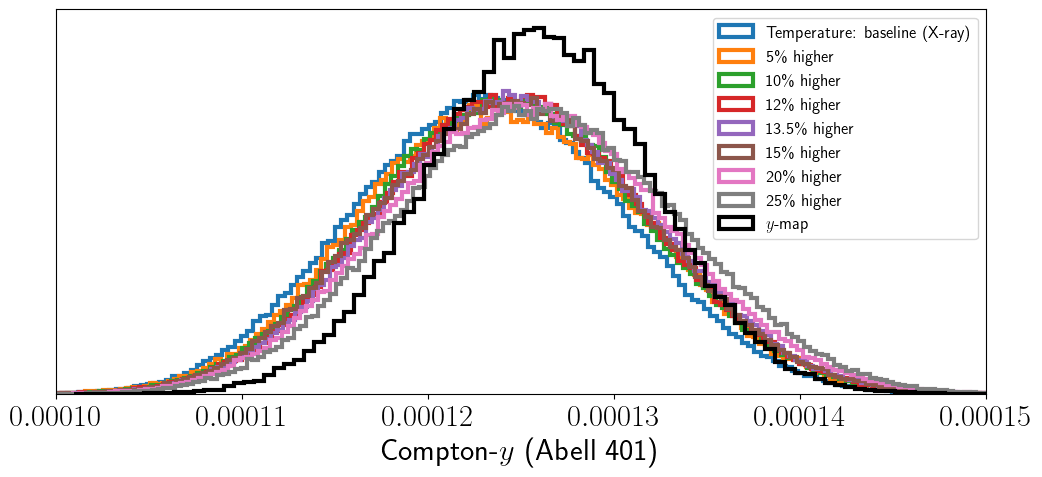

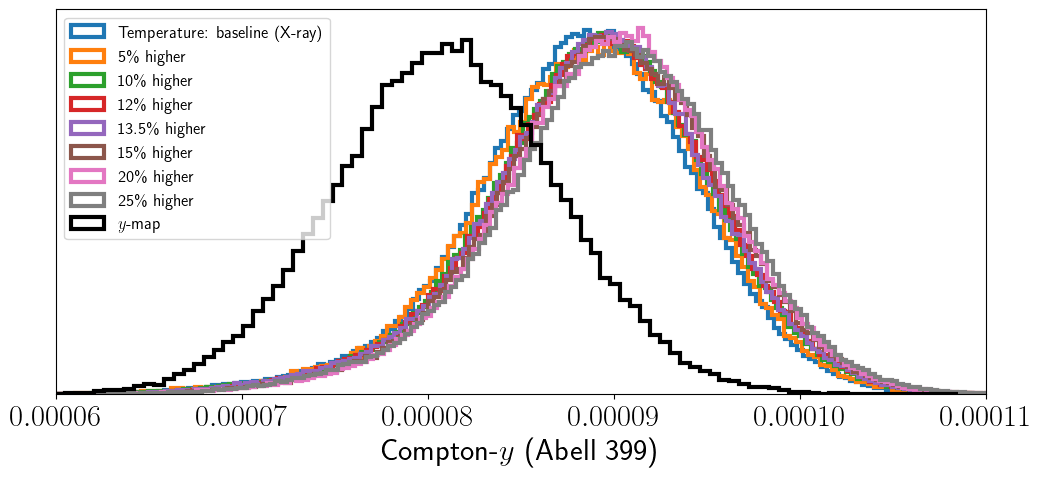

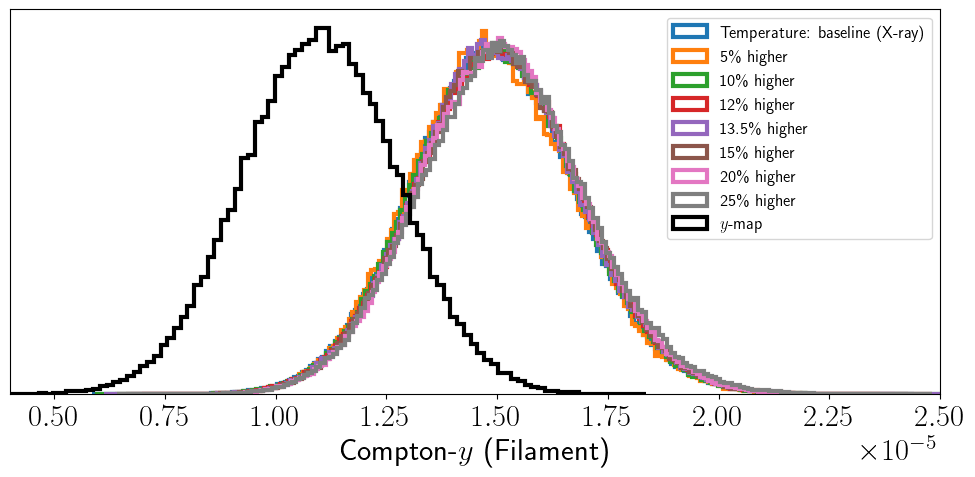

In [17]:
# plot the y distributions for each case
plt.figure(figsize=(12, 5))
plt.hist(a401_y_vector_case10, bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(a401_y_vector_case24, bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(a401_y_vector_case25, bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
#plt.hist(a401_y_vector_case26, bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case27, bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case28, bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case29, bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case30, bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case31, bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case32, bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(a401_y_vector_case33, bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 100000), 
         histtype='step', color='black', linestyle='-',
         bins=100, alpha=1, label='$y$-map', density=True, lw=3)
plt.xlabel('Compton-$y$ (Abell 401)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("compton_y_a401_distributions.png", bbox_inches='tight')
plt.xlim(0.0001, 0.00015)
plt.show()

# plot the y distributions for A399
plt.figure(figsize=(12, 5))
plt.hist(a399_y_vector_case10, bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(a399_y_vector_case24, bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)    
#plt.hist(a399_y_vector_case25, bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
#plt.hist(a399_y_vector_case26, bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case27, bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case28, bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case29, bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case30, bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case31, bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case32, bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(a399_y_vector_case33, bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 100000), 
         histtype='step', 
         bins=100, alpha=1, label='$y$-map', density=True, lw=3, color='black', linestyle='-')
plt.xlabel('Compton-$y$ (Abell 399)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("compton_y_a399_distributions.png", bbox_inches='tight')
plt.xlim(0.00006, 0.00011)
plt.show()

# plot the y distributions for Filament
plt.figure(figsize=(12, 5))
plt.hist(fil_y_vector_case10, bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(fil_y_vector_case24, bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(fil_y_vector_case25, bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
#plt.hist(fil_y_vector_case26, bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case27, bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case28, bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case29, bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case30, bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case31, bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case32, bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(fil_y_vector_case33, bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 100000), 
         histtype='step', 
         bins=100, alpha=1, label='$y$-map', density=True, lw=3, color='black', linestyle='-')
plt.xlabel('Compton-$y$ (Filament)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("compton_y_filament_distributions.png", bbox_inches='tight')
plt.xlim(0.000004, 0.000025)
plt.show()


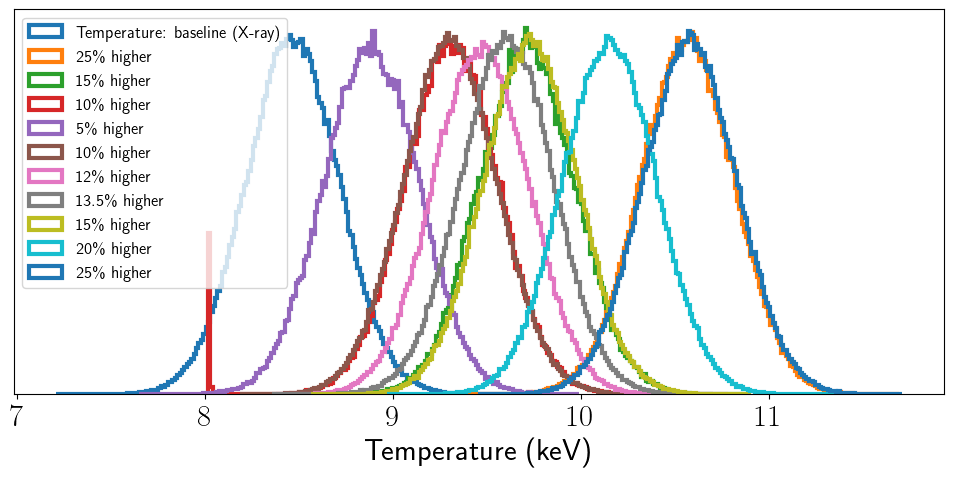

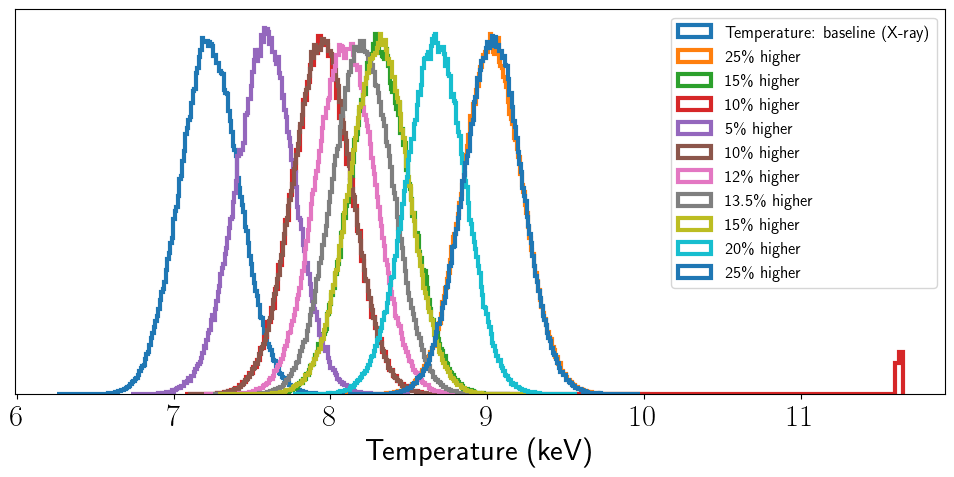

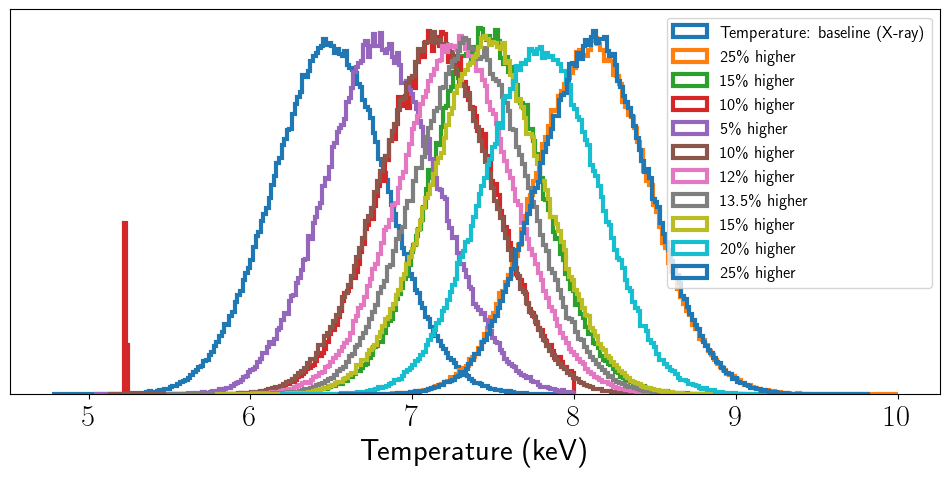

In [13]:
# Te distributions for each case
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a401_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for A399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)     
plt.hist(samples_case27[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a399_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for Filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)  
plt.hist(samples_case24[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_filament_distributions.png", bbox_inches='tight')
plt.show()

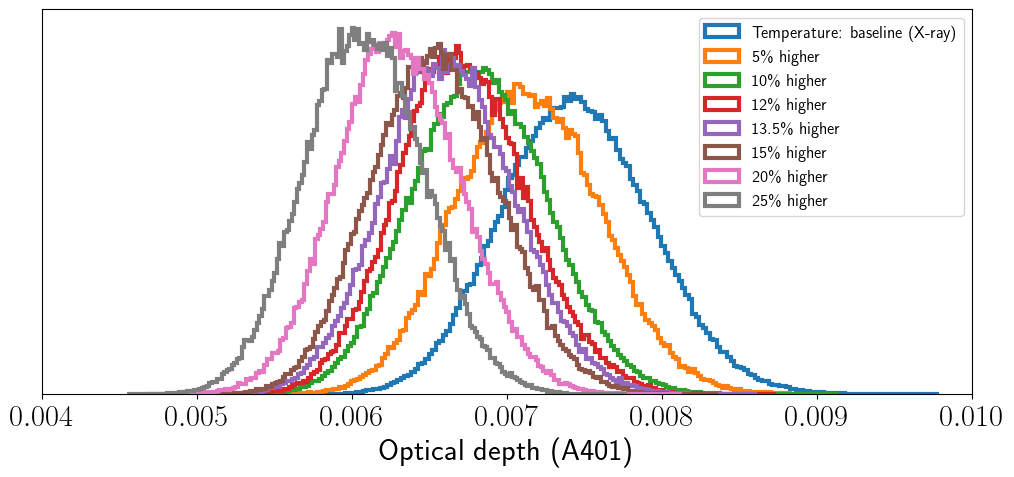

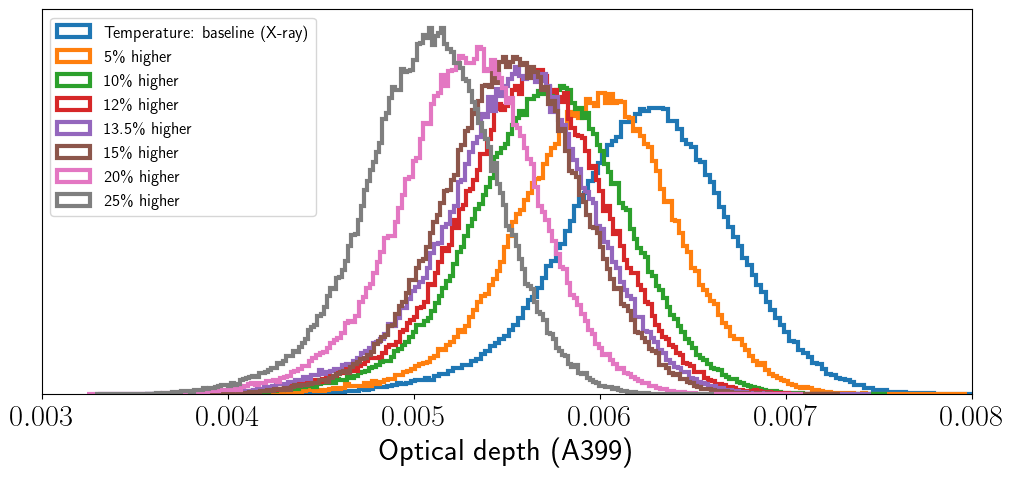

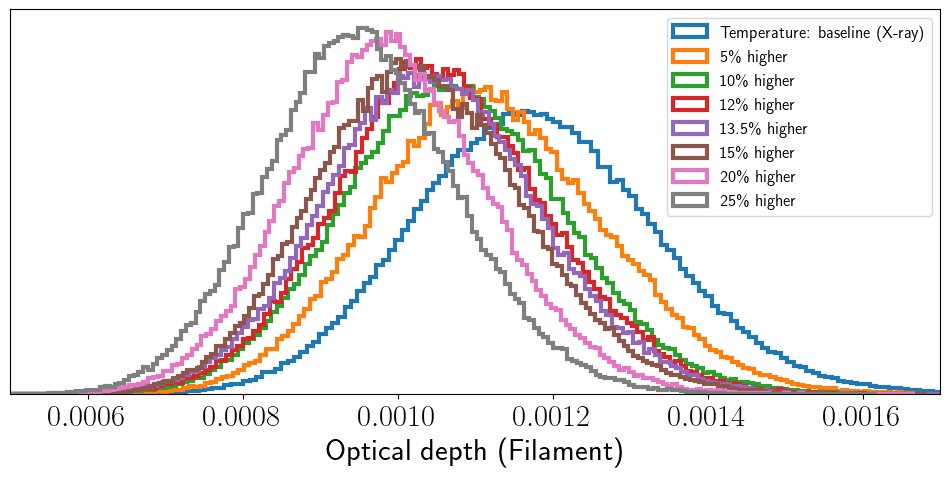

In [22]:
# tau histograms for a401   
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)    
plt.hist(samples_case32[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A401)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.004, 0.01)
#plt.savefig("tau_a401_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for a399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)    
# plt.hist(samples_case26[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A399)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.003, 0.008)
#plt.savefig("tau_a399_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (Filament)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.0005, 0.0017)
#plt.savefig("tau_filament_distributions.png", bbox_inches='tight')
plt.show()

In [ ]:
# plot the histograms of the temperature for each case with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# A401 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a401 = samples[:, param_indices['Te_a401']]
    axes[0].hist(Te_a401, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[0].set_xlabel('Temperature (keV)')
axes[0].set_ylabel('Density')
axes[0].set_title('A401 Temperature Distributions')
axes[0].legend()

# A399 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a399 = samples[:, param_indices['Te_a399']]
    axes[1].hist(Te_a399, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[1].set_xlabel('Temperature (keV)')
axes[1].set_ylabel('Density')
axes[1].set_title('A399 Temperature Distributions')
axes[1].legend()

# Filament temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_fil = samples[:, param_indices['Te_fil']]
    axes[2].hist(Te_fil, bins=50, alpha=1, lw=3, label=f'{case_name}', density=True, histtype='step')
axes[2].set_xlabel('Temperature (keV)')
axes[2].set_ylabel('Density')
axes[2].set_title('Filament Temperature Distributions')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        cf['region_width'])

dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                            box=region))

plate_scale = 0.5
r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

In [ ]:
from pixell import colorize
colorize.mpl_register("planck")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap, reproject
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

# ---- Read and Prepare Map ----
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], cf['region_center_dec'], 1.*cf['region_width'])
dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"

data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", box=region))

# ---- Physical Parameters ----
plate_scale = 0.5  # arcmin/pixel

r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

# ---- Setup WCS and Plot ----
wcs = data_ref.wcs
shape = data_ref.shape

fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(projection=(wcs))

im = ax.imshow(data_ref, origin='lower', cmap='planck')
ax.invert_xaxis()  # Invert x-axis for RA
plt.colorbar(im, ax=ax, orientation='vertical', label='$\mu$K')

def draw_circle(ax, ra, dec, radius, **kwargs):
    """Draw a circle at (ra, dec) with radius in arcmin."""
    center = SkyCoord(ra*u.deg, dec*u.deg)
    theta = np.linspace(0, 2*np.pi, 200)
    offset = radius.to(u.deg).value
    ras = center.ra.deg + offset * np.cos(theta) / np.cos(np.deg2rad(center.dec.deg))
    decs = center.dec.deg + offset * np.sin(theta)
    ax.plot(ras, decs, transform=ax.get_transform('world'), **kwargs)

# ---- Draw circles ----
draw_circle(ax, ra_center_a401, dec_center_a401, r500_a401, color='black', lw=2, ls='-',label='$R_{500c}$ (A401)')
draw_circle(ax, ra_center_a401, dec_center_a401, r_core_a401, color='black', lw=1, ls='--', label=r'$R_{\rm core}$ (A401)')
draw_circle(ax, ra_center_a399, dec_center_a399, r500_a399, color='red', lw=2, ls='-',label='$R_{500c}$ (A399)')
draw_circle(ax, ra_center_a399, dec_center_a399, r_core_a399, color='red', lw=1, ls='--', label=r'$R_{\rm core}$ (A399)')

# ---- Plot Formatting ----
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend(loc='upper right', fontsize=14, facecolor='white', edgecolor='black', framealpha=1.0)

# add a text box with white background towards the bottom center of the plot saying "ACT PA5 f90"
textstr = 'ACT PA5 (90 GHz)'
props = dict(boxstyle='round', facecolor='white', alpha=1)
ax.text(0.5, 0.05, textstr, transform=ax.transAxes, fontsize=15,
        verticalalignment='center', horizontalalignment='center', bbox=props)
plt.tight_layout()
plt.savefig("../plots/map_r500_core.pdf", dpi=300, bbox_inches='tight')
plt.show()
